In [1]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the CarDekho dataset
df = pd.read_csv("car data.csv")

# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [4]:
# Check for missing values in every column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [5]:
# Check how many duplicate rows are present
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [6]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check the cleaned column names
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [7]:
# Remove rows containing missing values
df = df.dropna().copy()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (301, 9)


In [8]:
# Remove duplicate records
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [9]:
# Check unique values in important categorical columns

print("Fuel Types:")
print(df["Fuel_Type"].unique())

print("\nTransmission Types:")
print(df["Transmission"].unique())

print("\nSeller Types:")
print(df["Seller_Type"].unique())

print("\nOwner Types:")
print(df["Owner"].unique())

Fuel Types:
['Petrol' 'Diesel' 'CNG']

Transmission Types:
['Manual' 'Automatic']

Seller Types:
['Dealer' 'Individual']

Owner Types:
[0 1 3]


In [10]:
# Standardize categorical text values
categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner"
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

# Check the cleaned values
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Fuel_Type:
['Petrol' 'Diesel' 'Cng']

Seller_Type:
['Dealer' 'Individual']

Transmission:
['Manual' 'Automatic']

Owner:
['0' '1' '3']


In [11]:
# Standardize categorical text values

categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

# Convert Owner to string for consistent categorical handling
df["Owner"] = df["Owner"].astype(str).str.strip()

# Check the cleaned values
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Fuel_Type:
['Petrol' 'Diesel' 'Cng']

Seller_Type:
['Dealer' 'Individual']

Transmission:
['Manual' 'Automatic']


In [12]:
# Extract the car brand from the car name
df["Brand"] = df["Car_Name"].str.split().str[0]

# Display car names and extracted brands
df[["Car_Name", "Brand"]].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [13]:
# Calculate the age of each car
reference_year = df["Year"].max()

df["Car_Age"] = reference_year - df["Year"]

# Display year and calculated car age
df[["Year", "Car_Age"]].head(10)

,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4
5,2018,0
6,2015,3
7,2015,3
8,2016,2
9,2015,3


In [14]:
# Check the updated dataset
print("Final Shape:", df.shape)

print("\nUpdated Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Final Shape: (299, 11)

Updated Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Brand', 'Car_Age']

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Brand            0
Car_Age          0
dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,ritz,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,sx4,5
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,ciaz,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,wagon,7
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,swift,4


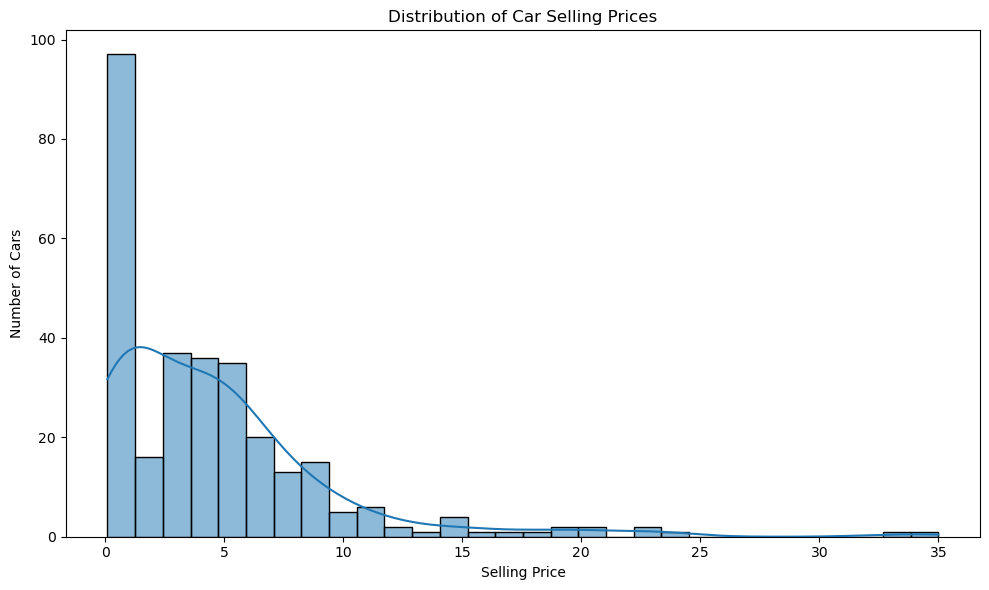

In [15]:
# Visualize the distribution of car selling prices

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Selling_Price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

### Observation

The selling price distribution shows that most cars in the dataset are concentrated within the lower price range, while comparatively fewer vehicles have higher selling prices. This indicates that the dataset contains more affordable used cars than expensive ones.


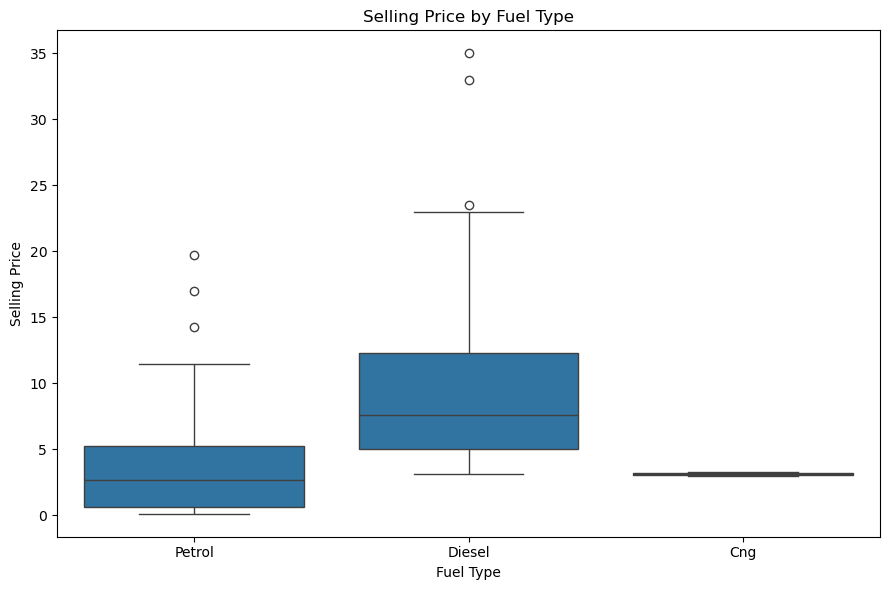

In [16]:
# Compare selling prices across different fuel types

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

### Observation

The box plot shows differences in selling prices across fuel categories. The distribution and spread of prices vary between fuel types, suggesting that fuel type may contribute useful information when predicting the selling price of a used car.


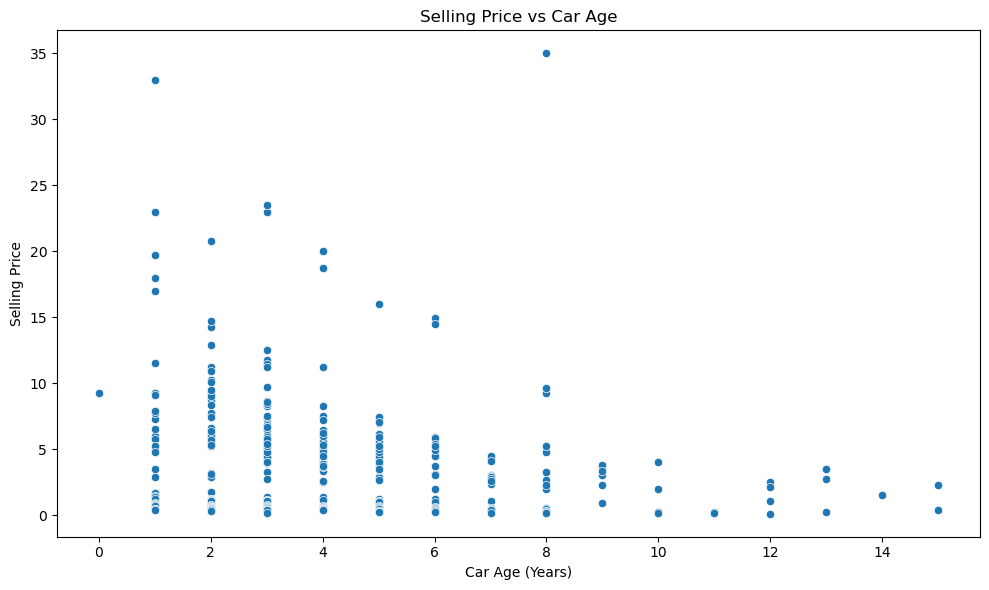

In [17]:
# Visualize the relationship between car age and selling price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

### Observation

The scatter plot indicates that selling prices generally tend to decrease as the age of a car increases. Newer vehicles are usually associated with higher selling prices, while older vehicles tend to have lower prices. However, the relationship is not perfectly linear because other factors also influence the value of a used car.


In [18]:
# Select numerical columns for correlation analysis

numerical_features = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Car_Age"
]

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

# Display correlation values
correlation_matrix

,Year,Selling_Price,Present_Price,Kms_Driven,Car_Age
Year,1.000000,0.234369,-0.053563,-0.525714,-1.000000
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.234369
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.053563
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.525714
Car_Age,-1.000000,-0.234369,0.053563,0.525714,1.000000


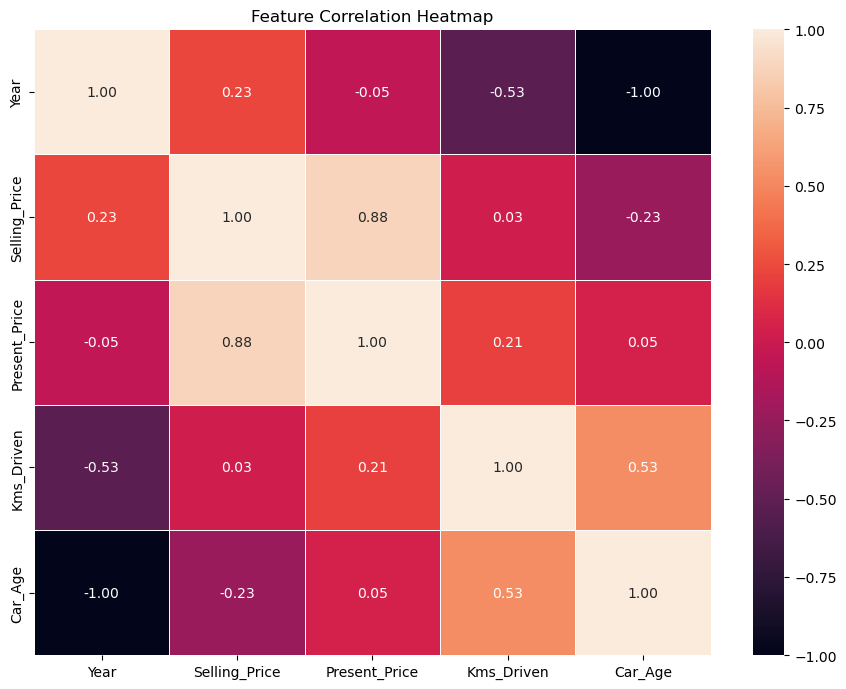

In [19]:
# Visualize correlations using a heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between the numerical variables in the dataset. Selling price has a strong positive relationship with present price, indicating that cars with higher current market prices generally have higher selling prices.

Car age and selling price tend to have an inverse relationship, suggesting that older vehicles generally have lower selling prices. Mileage also provides useful information about a vehicle's value.

In [20]:
# Define the features used for prediction
features = [
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "Brand",
    "Car_Age"
]

# Define input features and target variable
X = df[features]
y = df["Selling_Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (299, 8)
Target shape: (299,)


In [21]:
# Identify numerical and categorical features

numerical_columns = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Brand"
]

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
Categorical columns: ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']


In [22]:
# Create a preprocessing step for categorical variables
# OneHotEncoder converts categories into numerical columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [23]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 239
Testing samples: 60


### Data Preparation

The dataset was divided into training and testing sets using an 80/20 split. Numerical features were retained in their original form, while categorical variables were prepared for One-Hot Encoding.

The `Brand` and `Car_Age` features created during feature engineering were also included because they may provide additional information for estimating a vehicle's selling price.


In [24]:
# Create a Linear Regression pipeline
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

# Generate predictions on test data
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Create a Random Forest regression pipeline
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Generate predictions
random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

In [ ]:
# Function to calculate regression evaluation metrics

def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return mae, rmse, r2

In [ ]:
# Evaluate Linear Regression
linear_mae, linear_rmse, linear_r2 = evaluate_model(
    y_test,
    linear_predictions
)

# Evaluate Random Forest
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    random_forest_predictions
)

print("Linear Regression")
print("-----------------")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

print("\nRandom Forest Regressor")
print("----------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

In [ ]:
# Create a comparison table for both models

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

# Round numerical values for easier reading
model_comparison[
    ["MAE", "RMSE", "R2 Score"]
] = model_comparison[
    ["MAE", "RMSE", "R2 Score"]
].round(3)

model_comparison

## Model Comparison

Two regression models were tested: Linear Regression and Random Forest Regressor.

Linear Regression achieved an MAE of 1.348, an RMSE of 2.389, and an R² score of 0.779. Random Forest Regressor achieved an MAE of 1.397, an RMSE of 3.368, and an R² score of 0.560.

### Best Performing Model

Based on all three evaluation metrics, Linear Regression performed better than Random Forest Regressor on the test dataset. It produced lower MAE and RMSE values and a higher R² score.

Therefore, **Linear Regression is selected as the best-performing model for this project**. Its R² score of 0.779 indicates that the model explains a substantial portion of the variation in selling prices within the test data.


In [ ]:
# Get the fitted preprocessor from the trained Linear Regression pipeline
fitted_preprocessor = linear_model.named_steps["preprocessor"]

# Get names of the one-hot encoded categorical features
encoded_feature_names = fitted_preprocessor.named_transformers_[
    "categorical"
].get_feature_names_out(categorical_columns)

# Combine encoded categorical features with numerical features
all_feature_names = list(encoded_feature_names) + numerical_columns

# Get Linear Regression coefficients
coefficients = linear_model.named_steps["regressor"].coef_

# Create a DataFrame containing feature coefficients
feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

# Calculate absolute coefficient magnitude
feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

In [ ]:
# Select the 15 most influential features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Linear Regression")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Feature Importance

The feature importance analysis shows which variables have the strongest influence on the Linear Regression model's predictions. The magnitude of a regression coefficient indicates how strongly the corresponding feature contributes to the predicted selling price, while the sign indicates whether the relationship is positive or negative.

The results show that some vehicle characteristics have a considerably stronger influence on predicted selling prices than others. This analysis helps identify the features that contribute most to the model's price predictions.


## Final Conclusion

This project developed a machine learning system to predict the selling price of used cars using vehicle-related features. The dataset was cleaned by handling missing values, removing duplicate records, and standardizing categorical information.

Feature engineering was performed by extracting the car brand from the vehicle name and calculating the age of each car from its manufacturing year. Exploratory data analysis was then used to understand the distribution of selling prices and the relationship between price and different vehicle characteristics.

Categorical variables were converted into numerical representations using One-Hot Encoding. Two regression algorithms, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² score.

Linear Regression achieved an MAE of **1.348**, an RMSE of **2.389**, and an R² score of **0.779**. Random Forest Regressor achieved an MAE of **1.397**, an RMSE of **3.368**, and an R² score of **0.560**.

Based on these evaluation results, **Linear Regression was selected as the best-performing model** because it produced lower MAE and RMSE values and a higher R² score than Random Forest Regressor on the test dataset.

The feature coefficient analysis also provided insight into which vehicle characteristics had the strongest influence on the model's predictions.

Overall, the project demonstrates how data cleaning, feature engineering, exploratory analysis, categorical encoding, and regression algorithms can be combined to build a used-car price prediction system.
